# Model Building

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [4]:
# 1. Load the featured data
df = pd.read_csv("fraud_featured.csv")

In [6]:
# 2. Separate features and target
X = df.drop(columns=['Fraudulent'])
y = df['Fraudulent']

In [7]:
# 3. Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain Fraud %:", y_train.mean().round(4)*100)
print("Test Fraud %:", y_test.mean().round(4)*100)

Train shape: (4000, 17)
Test shape: (1000, 17)

Train Fraud %: 9.65
Test Fraud %: 9.6


In [8]:
# 4. Handle Class Imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE - Train shape:", X_train_smote.shape)
print("After SMOTE - Fraud count:", y_train_smote.sum())


After SMOTE - Train shape: (7228, 17)
After SMOTE - Fraud count: 3614


In [9]:
# 5. Train Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n===== {name} =====")
    model.fit(X_train_smote, y_train_smote)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(classification_report(y_test, y_pred))
    print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))
    
    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_prob": y_prob
    }


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.97      0.72      0.82       904
           1       0.22      0.76      0.34        96

    accuracy                           0.72      1000
   macro avg       0.59      0.74      0.58      1000
weighted avg       0.89      0.72      0.78      1000

ROC-AUC Score: 0.8227

===== Random Forest =====
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       904
           1       0.22      0.27      0.24        96

    accuracy                           0.84      1000
   macro avg       0.57      0.59      0.58      1000
weighted avg       0.85      0.84      0.85      1000

ROC-AUC Score: 0.8397

===== XGBoost =====
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       904
           1       0.36      0.26      0.30        96

    accuracy                           0.89      1000
   

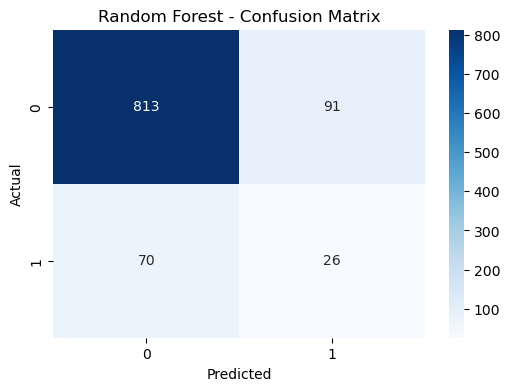


 Model Building Completed!


In [10]:
# 6. Confusion Matrix for best model (example: Random Forest)
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, results["Random Forest"]["y_pred"])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n Model Building Completed!")